In [ ]:
from google.colab import files
uploaded = files.upload(

)

Saving BAJFINANCE.NS (4).csv to BAJFINANCE.NS (4).csv


In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('/content/BAJFINANCE.NS (4).csv')

In [ ]:
print(df.info())
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%y')
df = df.sort_values(by='Date')
df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month
df['day'] = df['Date'].dt.day
df['dayofweek'] = df['Date'].dt.dayofweek
df['Close_lag1'] = df['Close'].shift(1)
df['Close_lag2'] = df['Close'].shift(2)
df.dropna(inplace=True)
display(df.head())

<class 'pandas.core.frame.DataFrame'>
Index: 4963 entries, 2 to 4994
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Date        4963 non-null   datetime64[ns]
 1   Open        4963 non-null   float64       
 2   High        4963 non-null   float64       
 3   Low         4963 non-null   float64       
 4   Close       4963 non-null   float64       
 5   Adj Close   4963 non-null   float64       
 6   Volume      4963 non-null   float64       
 7   year        4963 non-null   int32         
 8   month       4963 non-null   int32         
 9   day         4963 non-null   int32         
 10  dayofweek   4963 non-null   int32         
 11  Close_lag1  4963 non-null   float64       
 12  Close_lag2  4963 non-null   float64       
dtypes: datetime64[ns](1), float64(8), int32(4)
memory usage: 465.3 KB
None


,Date,Open,High,Low,Close,Adj Close,Volume,year,month,day,dayofweek,Close_lag1,Close_lag2
4,2002-07-08,5.501093,5.718727,5.501093,5.625455,4.143462,48909.0,2002,7,8,0,5.590478,5.528297
5,2002-07-09,5.590478,5.758562,5.568132,5.616711,4.137022,321846.0,2002,7,9,1,5.625455,5.590478
6,2002-07-10,5.488462,5.488462,5.146465,5.222249,3.846478,138434.0,2002,7,10,2,5.616711,5.625455
7,2002-07-11,4.978382,5.213504,4.978382,5.186300,3.820000,15027.0,2002,7,11,3,5.222249,5.616711
8,2002-07-12,5.501093,5.501093,5.244595,5.319407,3.918040,24187.0,2002,7,12,4,5.186300,5.222249


In [ ]:
from sklearn.model_selection import train_test_split
X = df[['Open', 'High', 'Low', 'Volume', 'year', 'month', 'day', 'dayofweek', 'Close_lag1', 'Close_lag2']]
y = df['Close']
split_index = int(len(df) * 0.8)
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]
print(f"Training set size: {len(X_train)} samples")
print(f"Testing set size: {len(X_test)} samples")

Training set size: 3968 samples
Testing set size: 993 samples


Extra Trees Regressor Metrics:
MAE: 2040.13
RMSE: 2647.94


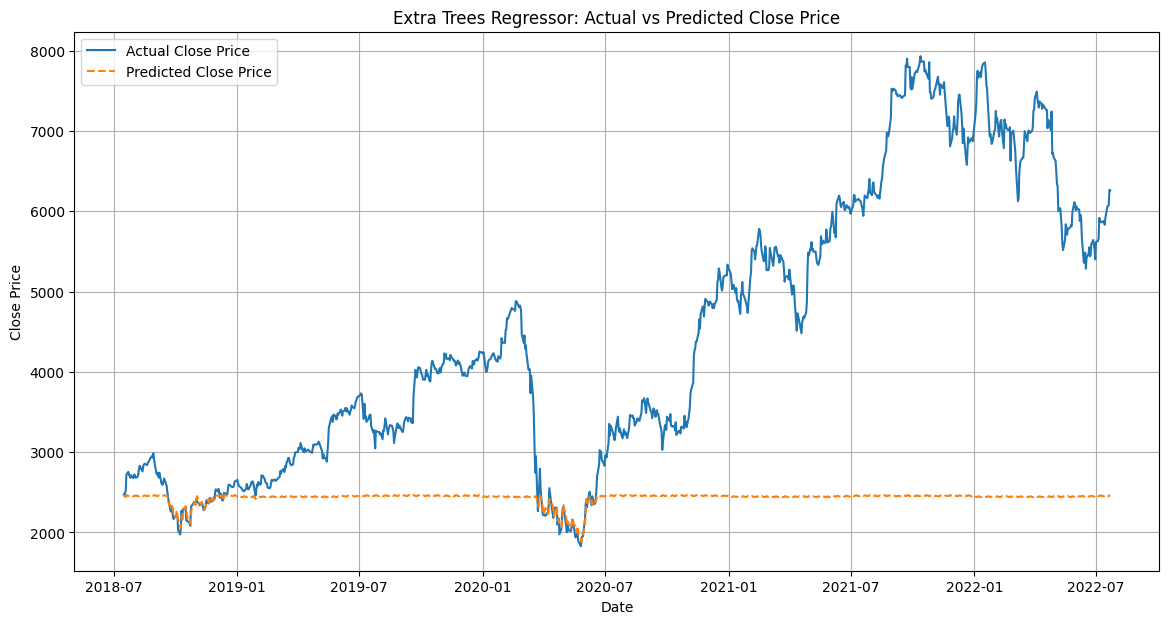

In [ ]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
et_model = ExtraTreesRegressor(n_estimators=100, random_state=42)
et_model.fit(X_train, y_train)
y_pred = et_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Extra Trees Regressor Metrics:\nMAE: {mae:.2f}\nRMSE: {rmse:.2f}")
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 7))
plt.plot(df['Date'][split_index:], y_test, label='Actual Close Price')
plt.plot(df['Date'][split_index:], y_pred, label='Predicted Close Price', linestyle='--')
plt.title('Extra Trees Regressor: Actual vs Predicted Close Price')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.show()

Top 10 most anomalous data points:


,Date,Open,High,Low,Close,Adj Close,Volume,year,month,day,dayofweek,Close_lag1,Close_lag2,anomaly_prediction,anomaly_score
4866,2022-01-17,7819.500000,7910.000000,7801.549805,7852.600098,7824.111816,679774.0,2022,1,17,0,7832.200195,7808.350098,-1,-0.042945
4868,2022-01-19,7850.000000,8045.000000,7473.000000,7571.799805,7544.330078,5000317.0,2022,1,19,2,7744.000000,7852.600098,-1,-0.037276
4865,2022-01-14,7775.000000,7846.100098,7728.500000,7832.200195,7803.785645,569635.0,2022,1,14,4,7808.350098,7774.500000,-1,-0.035661
4803,2021-10-18,8050.000000,8050.000000,7800.799805,7865.549805,7837.014648,855098.0,2021,10,18,0,7862.899902,7929.299805,-1,-0.035619
4861,2022-01-10,7686.000000,7759.000000,7669.750000,7731.299805,7703.251465,639060.0,2022,1,10,0,7659.350098,7748.250000,-1,-0.033081
4789,2021-09-27,7849.000000,7860.000000,7740.049805,7795.450195,7767.168945,650774.0,2021,9,27,0,7793.399902,7899.049805,-1,-0.032993
4860,2022-01-07,7763.950195,7785.000000,7585.000000,7659.350098,7631.562988,1165951.0,2022,1,7,4,7748.250000,7670.799805,-1,-0.031488
4867,2022-01-18,7899.950195,7945.000000,7716.049805,7744.000000,7715.905762,1130024.0,2022,1,18,1,7852.600098,7832.200195,-1,-0.029598
4864,2022-01-13,7828.000000,7849.549805,7774.000000,7808.350098,7780.021973,616374.0,2022,1,13,3,7774.500000,7669.850098,-1,-0.027201
4808,2021-10-25,7750.000000,7837.750000,7350.500000,7646.649902,7618.908691,1169729.0,2021,10,25,0,7710.200195,7737.299805,-1,-0.025762



Isolation Forest Results:
Total samples: 4961
Number of anomalies detected: 50
Percentage of anomalies: 1.01%


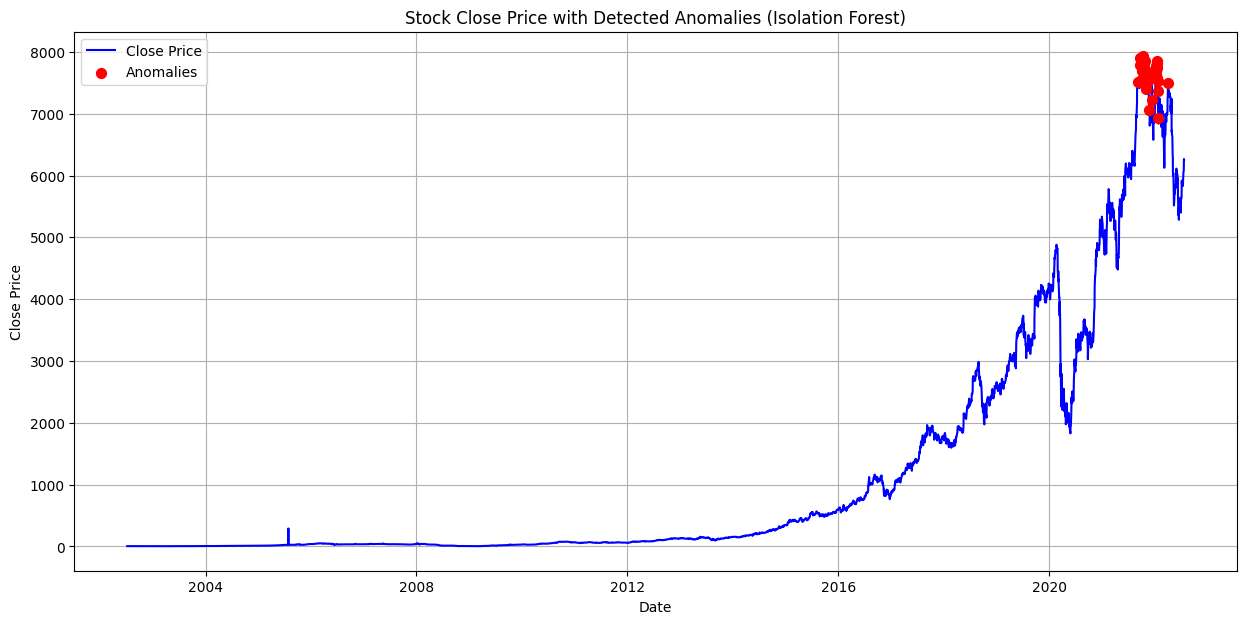

In [ ]:
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt
import numpy as np
iso_forest = IsolationForest(random_state=42, contamination=0.01)
iso_forest.fit(X)
anomaly_predictions = iso_forest.predict(X)
anomaly_scores = iso_forest.decision_function(X)
df_anomalies = df.copy()
df_anomalies['anomaly_prediction'] = anomaly_predictions
df_anomalies['anomaly_score'] = anomaly_scores
print("Top 10 most anomalous data points:")
display(df_anomalies.sort_values(by='anomaly_score').head(10))

num_anomalies = (anomaly_predictions == -1).sum()
total_samples = len(anomaly_predictions)
percentage_anomalies = (num_anomalies / total_samples) * 100
print(f"\nIsolation Forest Results:")
print(f"Total samples: {total_samples}")
print(f"Number of anomalies detected: {num_anomalies}")
print(f"Percentage of anomalies: {percentage_anomalies:.2f}%")

plt.figure(figsize=(15, 7))
plt.plot(df_anomalies['Date'], df_anomalies['Close'], label='Close Price', color='blue')
anomalies = df_anomalies[df_anomalies['anomaly_prediction'] == -1]
plt.scatter(anomalies['Date'], anomalies['Close'], color='red', label='Anomalies', s=50, zorder=5)
plt.title('Stock Close Price with Detected Anomalies (Isolation Forest)')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
print(f"\n--- Algorithm Accuracy Programs ---")
print(f"\nExtra Trees Regressor Metrics:")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

print(f"\nIsolation Forest Results:")
print(f"Total samples: {total_samples}")
print(f"Number of anomalies detected: {num_anomalies}")
print(f"Percentage of anomalies: {percentage_anomalies:.2f}%")
print(f"-----------------------------------")


--- Algorithm Accuracy Programs ---

Extra Trees Regressor Metrics:
MAE: 2040.13
RMSE: 2647.94

Isolation Forest Results:
Total samples: 4961
Number of anomalies detected: 50
Percentage of anomalies: 1.01%
-----------------------------------


In [ ]:
df.shape

(4961, 13)